# Exploratory Data Analysis

Ziel: Grundlegendes Verständnis des Datensatzes für das ML-Modell zur Vorhersage von `risk_flag`.

**Struktur:**
1. Datensatz laden & Überblick
2. Zielvariable
3. Missing Values & Imputation
4. Numerische Features: Verteilung & Skewness
5. Kategorische Features
6. Korrelationsanalyse
7. Multikollinearität (VIF)
8. Feature-Relevanz (bivariate Analyse)
9. Fazit & Empfehlungen

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

## 1. Datensatz laden & Überblick

In [59]:
df = pd.read_csv('../data/raw/train_full.csv', parse_dates=['timestamp'])
print(f'Shape: {df.shape}')
df.head()

Shape: (15000, 14)


,timestamp,transaction_volume,processing_time_hours,historical_incidents_90d,open_cases_count,customer_tenure_months,change_requests_30d,missing_docs_flag,high_priority_source_flag,region,channel,customer_segment,product_line,risk_flag
0,2025-01-01 00:03:00,52.660,16.070,2,3,92.300,1,0,0,west,email,mid,beta,0
1,2025-01-01 00:12:00,15.940,16.220,2,2,41.100,0,0,0,west,web,small,alpha,0
2,2025-01-01 00:13:00,55.270,17.460,5,5,49.000,2,0,0,west,email,mid,alpha,1
3,2025-01-01 00:15:00,70.350,6.530,2,4,22.600,2,0,0,south,email,enterprise,beta,1
4,2025-01-01 00:25:00,70.430,12.250,0,3,38.000,1,0,0,north,partner,mid,delta,1


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   timestamp                  15000 non-null  datetime64[ns]
 1   transaction_volume         15000 non-null  float64       
 2   processing_time_hours      14764 non-null  float64       
 3   historical_incidents_90d   15000 non-null  int64         
 4   open_cases_count           15000 non-null  int64         
 5   customer_tenure_months     14725 non-null  float64       
 6   change_requests_30d        15000 non-null  int64         
 7   missing_docs_flag          15000 non-null  int64         
 8   high_priority_source_flag  15000 non-null  int64         
 9   region                     15000 non-null  object        
 10  channel                    14874 non-null  object        
 11  customer_segment           15000 non-null  object        
 12  prod

In [61]:
df.describe(include='all').round(2)

,timestamp,transaction_volume,processing_time_hours,historical_incidents_90d,open_cases_count,customer_tenure_months,change_requests_30d,missing_docs_flag,high_priority_source_flag,region,channel,customer_segment,product_line,risk_flag
count,15000,15000.000,14764.000,15000.000,15000.000,14725.000,15000.000,15000.000,15000.000,15000,14874,15000,15000,15000.000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,4,3,4,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,east,web,small,alpha,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3788,6593,8213,5235,NaN
mean,2025-02-26 20:06:28.527999744,49.630,20.350,1.610,3.490,36.180,1.780,0.120,0.200,NaN,NaN,NaN,NaN,0.340
min,2025-01-01 00:03:00,4.590,1.330,0.000,0.000,1.000,0.000,0.000,0.000,NaN,NaN,NaN,NaN,0.000
25%,2025-01-28 19:48:00,33.810,12.680,1.000,2.000,23.800,1.000,0.000,0.000,NaN,NaN,NaN,NaN,0.000
50%,2025-02-25 15:07:30,46.450,18.520,1.000,3.000,36.300,2.000,0.000,0.000,NaN,NaN,NaN,NaN,0.000
75%,2025-03-26 05:23:00,61.680,26.000,2.000,5.000,48.300,3.000,0.000,0.000,NaN,NaN,NaN,NaN,1.000
max,2025-04-30 23:59:00,175.520,106.220,9.000,12.000,101.700,8.000,1.000,1.000,NaN,NaN,NaN,NaN,1.000


In [62]:
# Feature-Typen aufteilen
TARGET = 'risk_flag'
DROP_COLS = ['timestamp']

num_cols = df.select_dtypes(include=np.number).columns.drop([TARGET]).tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

print('Numerische Features:', num_cols)
print('Kategorische Features:', cat_cols)

Numerische Features: ['transaction_volume', 'processing_time_hours', 'historical_incidents_90d', 'open_cases_count', 'customer_tenure_months', 'change_requests_30d', 'missing_docs_flag', 'high_priority_source_flag']
Kategorische Features: ['region', 'channel', 'customer_segment', 'product_line']


## 2. Zielvariable: `risk_flag`

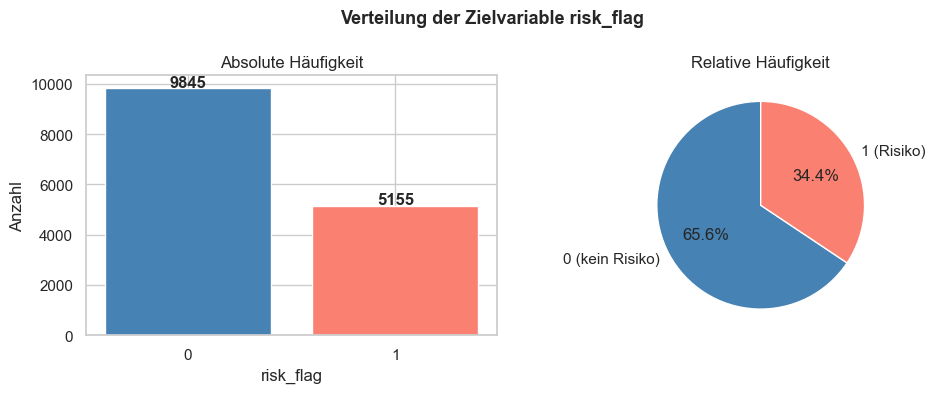


Klassenverteilung:
           Anzahl  Anteil (%)
risk_flag                    
0            9845      65.630
1            5155      34.370

Imbalance Ratio: 1.91


In [63]:
target_counts = df[TARGET].value_counts()
target_pct = df[TARGET].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(target_counts.index.astype(str), target_counts.values, color=['steelblue', 'salmon'])
axes[0].set_title('Absolute Häufigkeit')
axes[0].set_xlabel('risk_flag')
axes[0].set_ylabel('Anzahl')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(target_counts.values, labels=[f'0 (kein Risiko)', f'1 (Risiko)'],
            autopct='%1.1f%%', colors=['steelblue', 'salmon'], startangle=90)
axes[1].set_title('Relative Häufigkeit')

plt.suptitle('Verteilung der Zielvariable risk_flag', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nKlassenverteilung:')
print(pd.DataFrame({'Anzahl': target_counts, 'Anteil (%)': target_pct.round(2)}))

imbalance_ratio = target_counts.max() / target_counts.min()
print(f'\nImbalance Ratio: {imbalance_ratio:.2f}')
if imbalance_ratio > 3:
    print('=> Klassen-Ungleichgewicht vorhanden! Oversampling (SMOTE) oder class_weight empfohlen.')

## 3. Missing Values & Imputation

,Missing Count,Missing %,Dtype
customer_tenure_months,275,1.830,float64
processing_time_hours,236,1.570,float64
channel,126,0.840,object


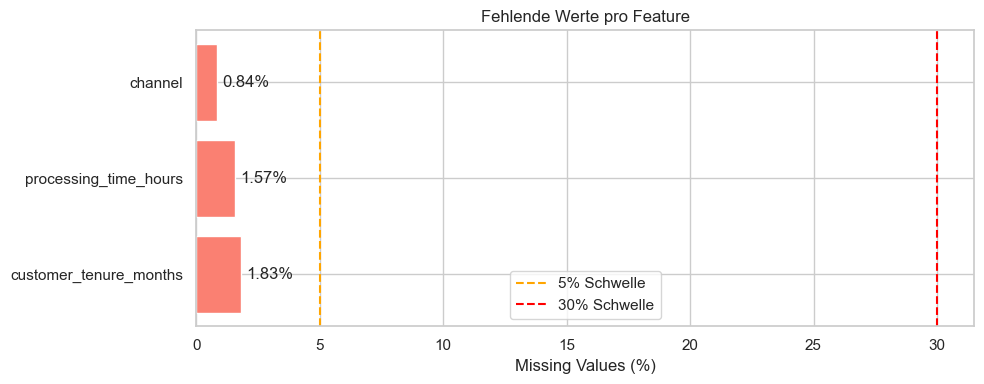


Imputation-Strategie (Empfehlung):
  customer_tenure_months: numerisch => Median-Imputation (robust gegen Ausreißer)
  processing_time_hours: numerisch => Median-Imputation (robust gegen Ausreißer)
  channel: kategorisch => Mode-Imputation oder Kategorie "Unknown"


In [64]:
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct,
    'Dtype': df.dtypes
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

if missing_df.empty:
    print('Keine Missing Values gefunden.')
else:
    display(missing_df)

    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_df) * 0.5)))
    bars = ax.barh(missing_df.index, missing_df['Missing %'], color='salmon')
    ax.set_xlabel('Missing Values (%)')
    ax.set_title('Fehlende Werte pro Feature')
    ax.axvline(x=5, color='orange', linestyle='--', label='5% Schwelle')
    ax.axvline(x=30, color='red', linestyle='--', label='30% Schwelle')
    ax.legend()
    for bar, val in zip(bars, missing_df['Missing %']):
        ax.text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val}%', va='center')
    plt.tight_layout()
    plt.show()

    print('\nImputation-Strategie (Empfehlung):')
    for col, row in missing_df.iterrows():
        if row['Missing %'] > 50:
            print(f'  {col}: >50% fehlen => Feature droppen oder als eigene Kategorie "missing" kodieren')
        elif row['Dtype'] == 'object':
            print(f'  {col}: kategorisch => Mode-Imputation oder Kategorie "Unknown"')
        else:
            print(f'  {col}: numerisch => Median-Imputation (robust gegen Ausreißer)')

## 4. Numerische Features: Verteilung & Skewness

In [65]:
skewness = df[num_cols].skew().sort_values(ascending=False)
kurtosis = df[num_cols].kurt().sort_values(ascending=False)

skew_df = pd.DataFrame({
    'Skewness': skewness,
    'Kurtosis': kurtosis
})
skew_df['Skew-Typ'] = skew_df['Skewness'].apply(
    lambda s: 'stark rechtsschief (>1)' if s > 1
    else ('stark linksschief (<-1)' if s < -1
    else ('mäßig schief' if abs(s) > 0.5 else 'symmetrisch'))
)

display(skew_df.style.background_gradient(subset=['Skewness'], cmap='RdYlGn_r'))

high_skew = skew_df[abs(skew_df['Skewness']) > 1].index.tolist()
print(f'\nFeatures mit |Skewness| > 1 (Transformation empfohlen): {high_skew}')

,Skewness,Kurtosis,Skew-Typ
change_requests_30d,0.770384,0.617646,mäßig schief
customer_tenure_months,0.114599,-0.292588,symmetrisch
high_priority_source_flag,1.521672,0.315529,stark rechtsschief (>1)
historical_incidents_90d,0.783961,0.629495,mäßig schief
missing_docs_flag,2.337031,3.462174,stark rechtsschief (>1)
open_cases_count,0.496369,0.224645,symmetrisch
processing_time_hours,1.152462,2.291081,stark rechtsschief (>1)
transaction_volume,0.886537,1.058725,mäßig schief



Features mit |Skewness| > 1 (Transformation empfohlen): ['high_priority_source_flag', 'missing_docs_flag', 'processing_time_hours']


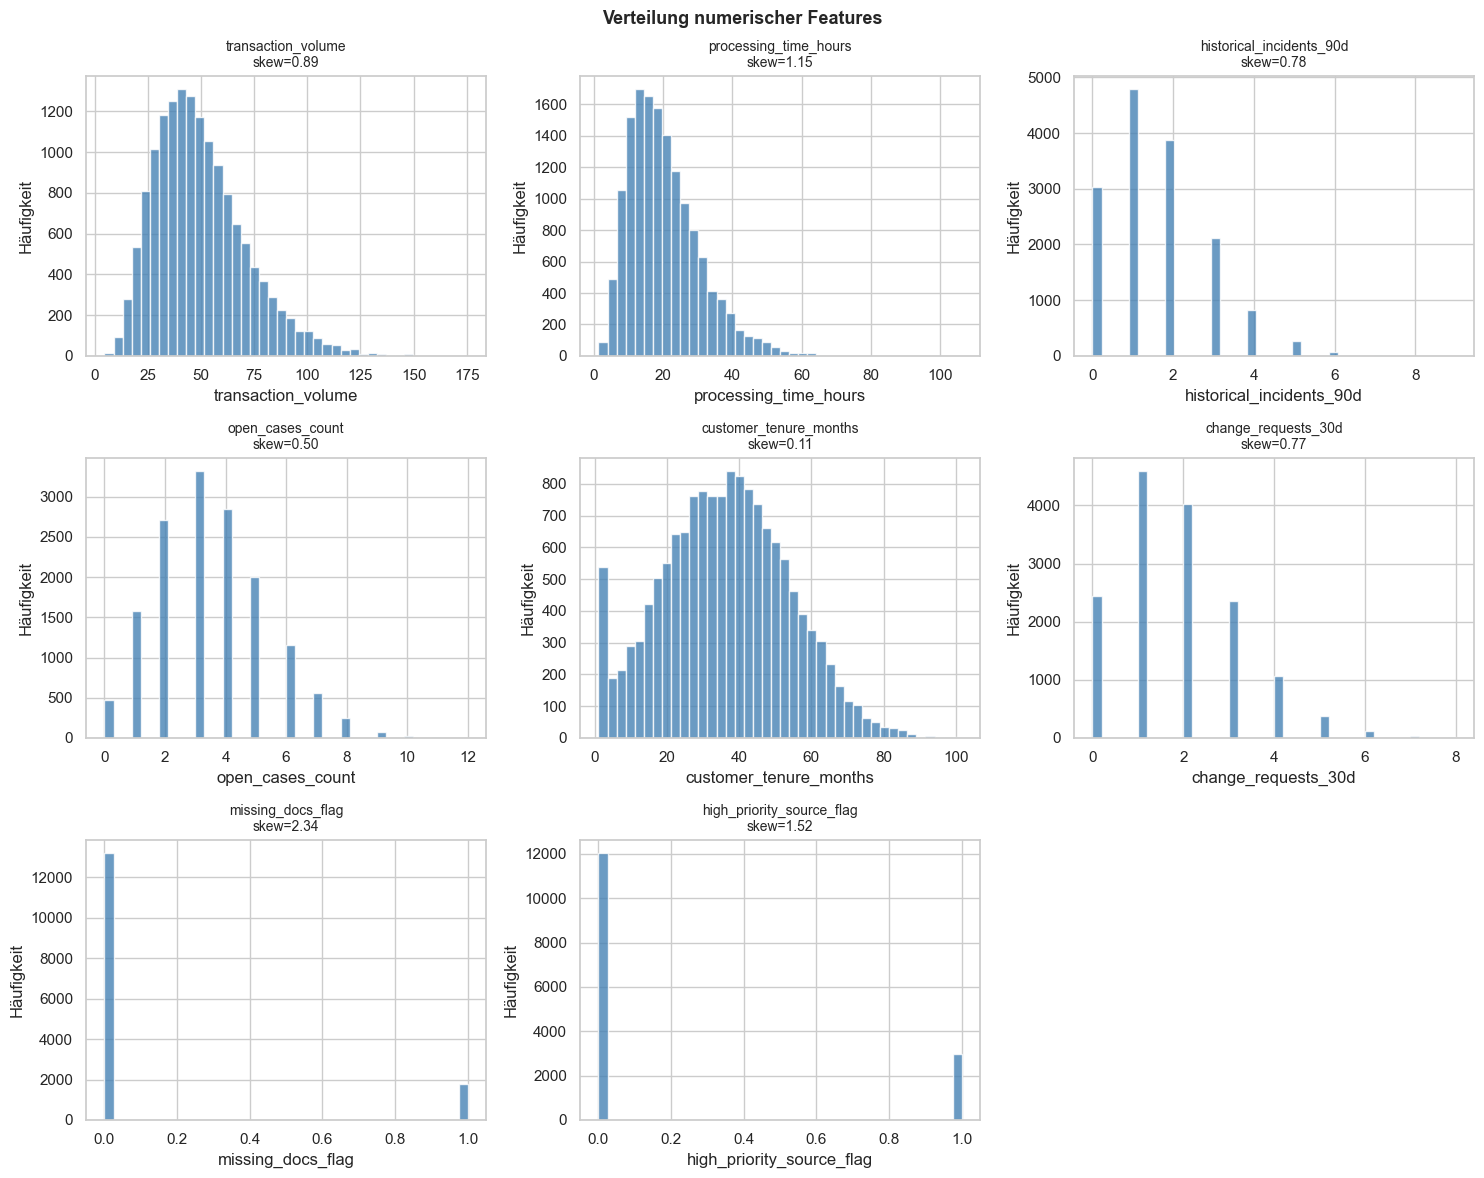

In [66]:
n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    ax.hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(f'{col}\nskew={df[col].skew():.2f}', fontsize=10)
    ax.set_xlabel(col)
    ax.set_ylabel('Häufigkeit')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Verteilung numerischer Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

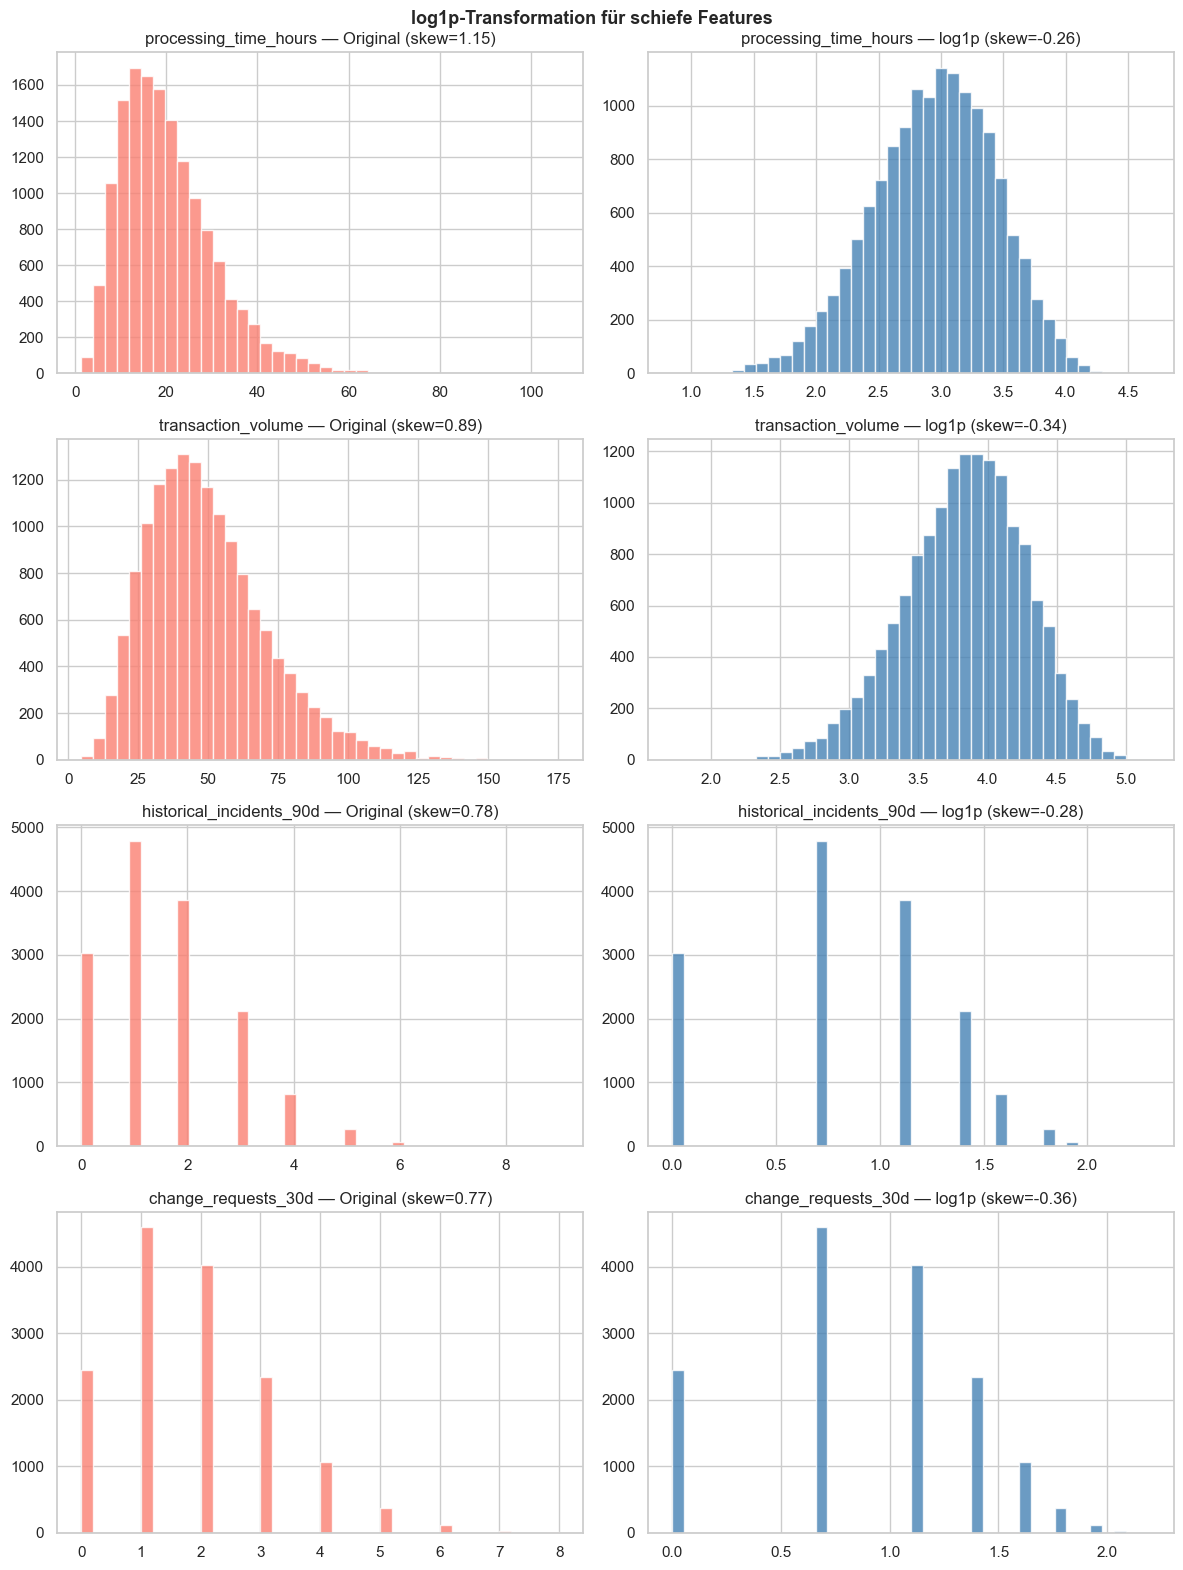

In [67]:
import numpy as np

# log1p-Transformation für schiefe Features (alle Werte positiv)
log1p_cols = ['processing_time_hours', 'transaction_volume', 'historical_incidents_90d', 'change_requests_30d']

fig, axes = plt.subplots(len(log1p_cols), 2, figsize=(12, 4 * len(log1p_cols)))

for i, col in enumerate(log1p_cols):
    data = df[col].dropna()
    transformed = np.log1p(data)

    axes[i][0].hist(data, bins=40, color='salmon', edgecolor='white', alpha=0.8)
    axes[i][0].set_title(f'{col} — Original (skew={data.skew():.2f})')

    axes[i][1].hist(transformed, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i][1].set_title(f'{col} — log1p (skew={transformed.skew():.2f})')

plt.suptitle('log1p-Transformation für schiefe Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Log-Transformation bei schiefen Features

Stark schiefe Features (|skew| > 0.75) können Modelle wie lineare Regression oder logistische Regression negativ beeinflussen, da diese implizit Symmetrie oder Normalverteilung der Eingaben annehmen.

**Welche Features werden transformiert?**

Da alle numerischen Features ausschließlich positive Werte haben, wird `log1p` verwendet:

| Feature | Skewness | Transformation |
|---|---|---|
| `processing_time_hours` | 1.15 | `log1p` |
| `transaction_volume` | 0.89 | `log1p` |
| `historical_incidents_90d` | 0.78 | `log1p` |
| `change_requests_30d` | 0.77 | `log1p` |
| `missing_docs_flag` | 2.34 | Binär — keine Transformation |
| `high_priority_source_flag` | 1.52 | Binär — keine Transformation |
| `open_cases_count` | 0.50 | kein Handlungsbedarf |
| `customer_tenure_months` | 0.12 | kein Handlungsbedarf |

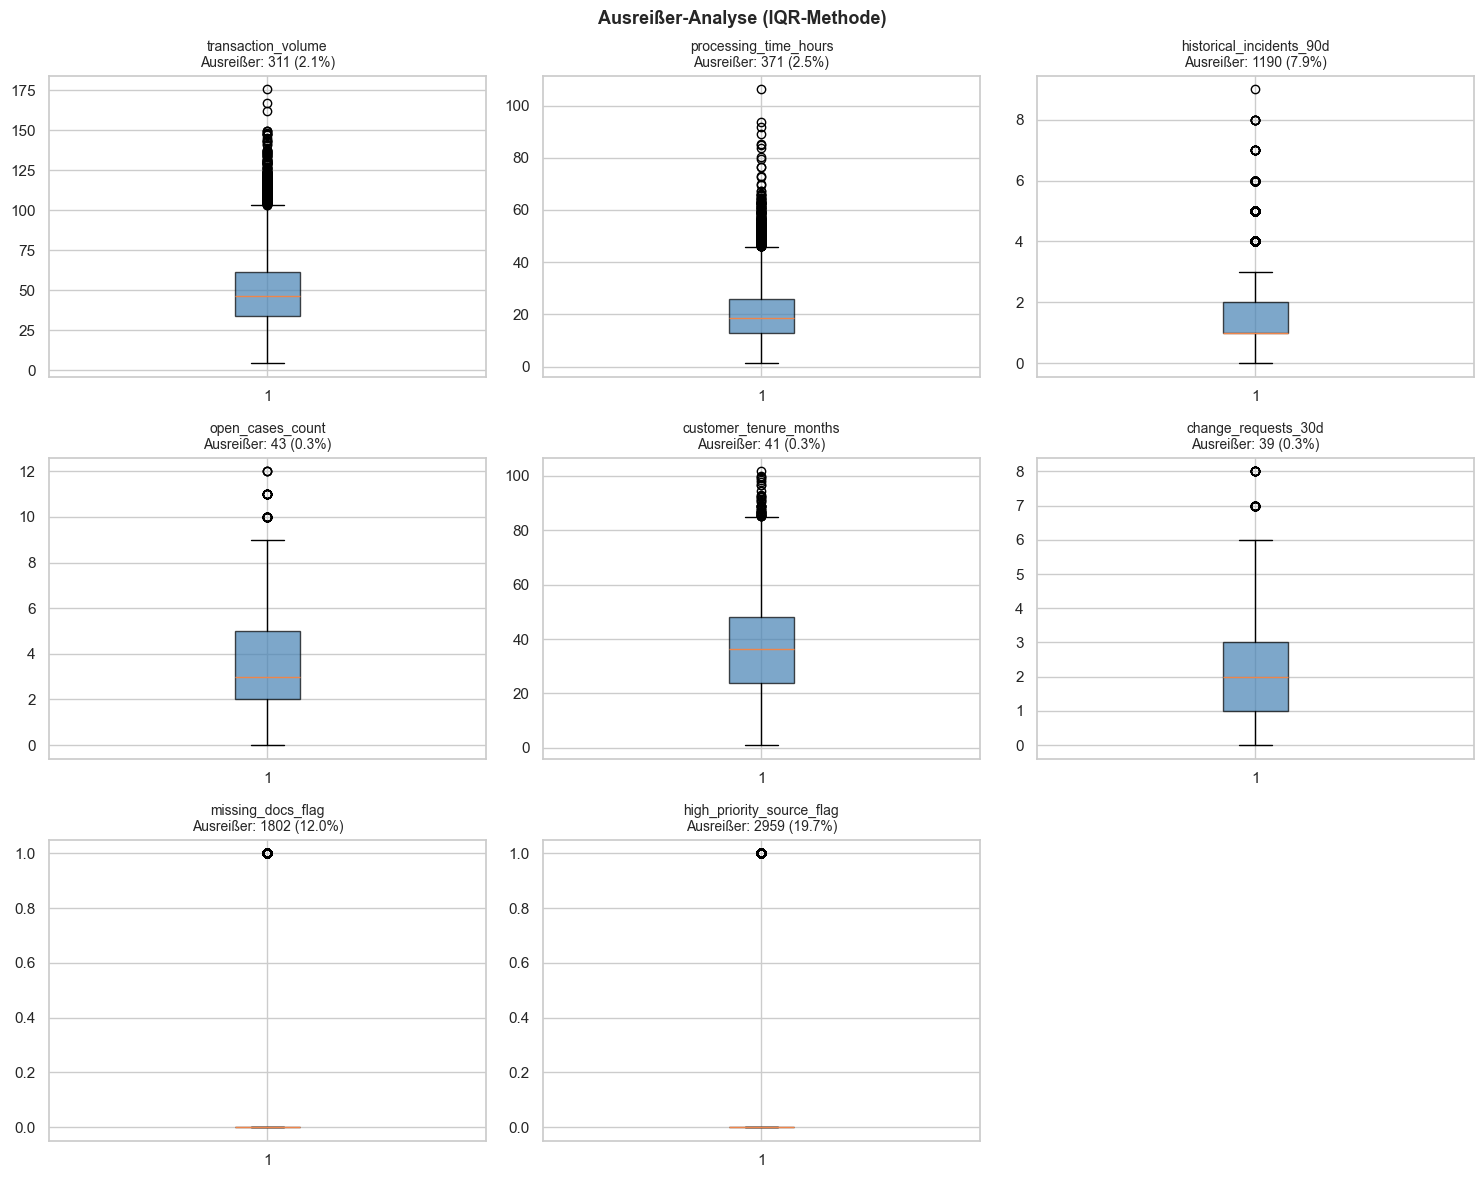

In [68]:
# Ausreißer-Analyse: Boxplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    data = df[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((data < Q1 - 1.5 * IQR) | (data > Q3 + 1.5 * IQR)).sum()
    outlier_pct = outliers / len(data) * 100

    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.7))
    ax.set_title(f'{col}\nAusreißer: {outliers} ({outlier_pct:.1f}%)', fontsize=10)
    ax.set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Ausreißer-Analyse (IQR-Methode)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretation: Ausreißer-Analyse (IQR-Methode)

**Echte Ausreißer (relevant):**

| Feature | Ausreißer | Auffälligkeit |
|---|---|---|
| `historical_incidents_90d` | 7.9% | Höchste Quote — Werte bis 8 bei Median ~1.5. Echte Extremfälle (Kunden mit sehr vielen Vorfällen). |
| `processing_time_hours` | 2.5% | Werte bis ~100 bei Median ~20. Könnte auf reale Verzögerungen/Sonderfälle hinweisen. |
| `transaction_volume` | 2.1% | Werte bis ~175 bei Median ~45. Typische Rechtsschiefe bei Volumendaten. |

**Unkritisch — IQR hier nicht sinnvoll:**

| Feature | "Ausreißer" | Grund |
|---|---|---|
| `missing_docs_flag` | 12.0% | Binäres Feature (0/1) — die "Ausreißer" sind einfach die Minderheitsklasse, keine echten Ausreißer. |
| `high_priority_source_flag` | 19.7% | Ebenfalls binär — IQR-Methode nicht anwendbar. |

**Handlungsempfehlung:**
- **Baumbasierte Modelle** (Random Forest, XGBoost): Ausreißer können so bleiben — Bäume sind robust dagegen.
- **Lineare / logistische Regression**: Ausreißer cappen, z. B. auf das 99. Perzentile.
- Binäre Features künftig aus der IQR-Analyse ausschließen.

## 5. Kategorische Features

In [69]:
for col in cat_cols:
    vc = df[col].value_counts()
    print(f'{col}: {df[col].nunique()} unique Werte')
    print(vc.to_string())
    print()

region: 4 unique Werte
region
east     3788
south    3787
north    3715
west     3710

channel: 4 unique Werte
channel
web        6593
email      3678
phone      3113
partner    1490

customer_segment: 3 unique Werte
customer_segment
small         8213
mid           4543
enterprise    2244

product_line: 4 unique Werte
product_line
alpha    5235
beta     4474
gamma    2960
delta    2331



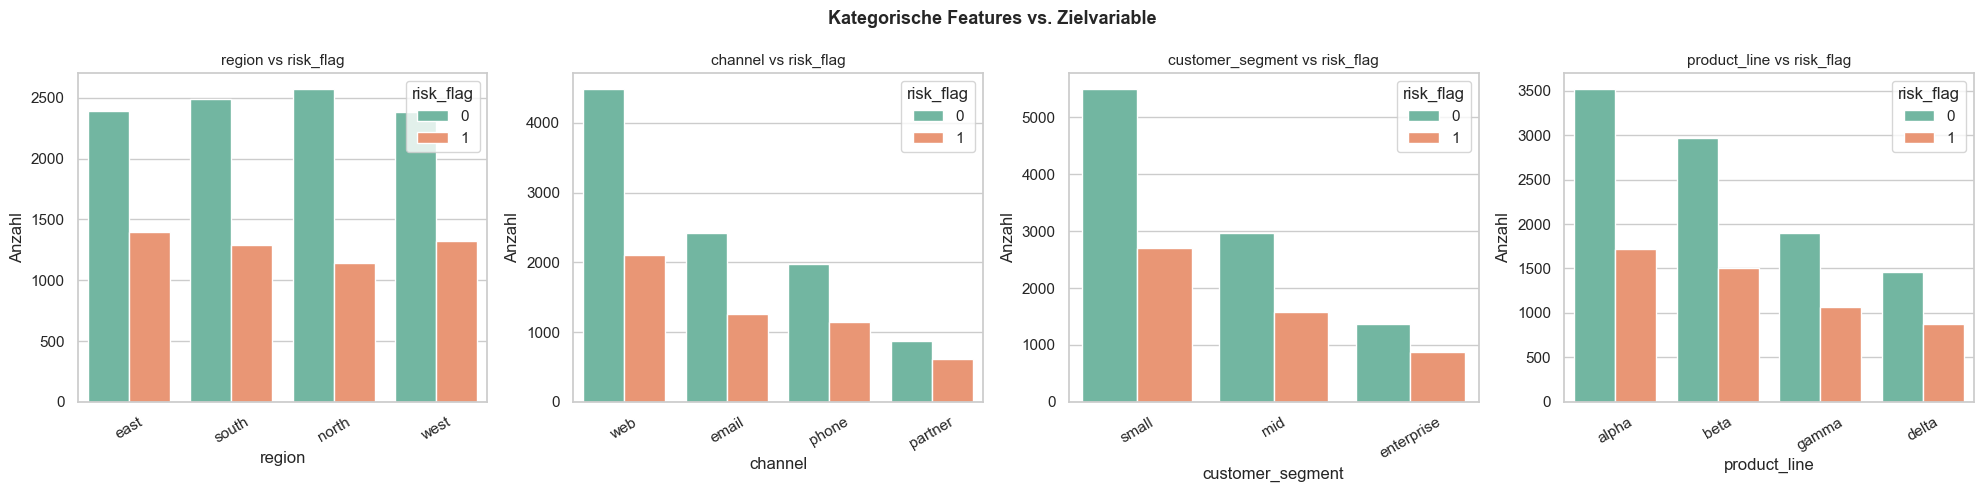

In [70]:
n_cat = len(cat_cols)
fig, axes = plt.subplots(1, n_cat, figsize=(5 * n_cat, 5))
if n_cat == 1:
    axes = [axes]

for ax, col in zip(axes, cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, hue=TARGET, order=order, ax=ax, palette='Set2')
    ax.set_title(f'{col} vs {TARGET}', fontsize=11)
    ax.set_xlabel(col)
    ax.set_ylabel('Anzahl')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='risk_flag', loc='upper right')

plt.suptitle('Kategorische Features vs. Zielvariable', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [71]:
# Risk-Rate pro Kategorie
print('Risk-Rate (Anteil risk_flag=1) pro kategorisches Feature:\n')
for col in cat_cols:
    risk_rate = df.groupby(col)[TARGET].mean().sort_values(ascending=False)
    print(f'--- {col} ---')
    print((risk_rate * 100).round(2).to_string(), '\n')

Risk-Rate (Anteil risk_flag=1) pro kategorisches Feature:

--- region ---
region
east    36.830
west    35.710
south   34.140
north   30.740 

--- channel ---
channel
partner   41.280
phone     36.680
email     34.120
web       31.940 

--- customer_segment ---
customer_segment
enterprise   38.810
mid          34.580
small        33.030 

--- product_line ---
product_line
delta   37.370
gamma   35.950
beta    33.620
alpha   32.780 



### Interpretation: Kategorische Features vs. Target

Alle 4 kategorialen Features sind laut Chi²-Test **statistisch signifikant** mit `risk_flag` assoziiert (p < 0.001) und sollten im Modell behalten werden.

Die Risk-Raten unterscheiden sich zwischen den Kategorien moderat:

| Feature | Niedrigste Risk-Rate | Höchste Risk-Rate | Spreizung |
|---|---|---|---|
| `channel` | web (31.9%) | partner (41.3%) | ~9 PP |
| `region` | north (30.7%) | east (36.8%) | ~6 PP |
| `customer_segment` | small (33.0%) | enterprise (38.8%) | ~6 PP |
| `product_line` | alpha (32.8%) | delta (37.4%) | ~5 PP |

**Muss man hier etwas tun?**  
Ja — für das Modell-Training ist ein **Encoding** notwendig, da Modelle numerische Inputs erwarten: Da alle Features nur 3–4 Kategorien haben, ist One-Hot Encoding empfohlen.

## 6. Korrelationsanalyse

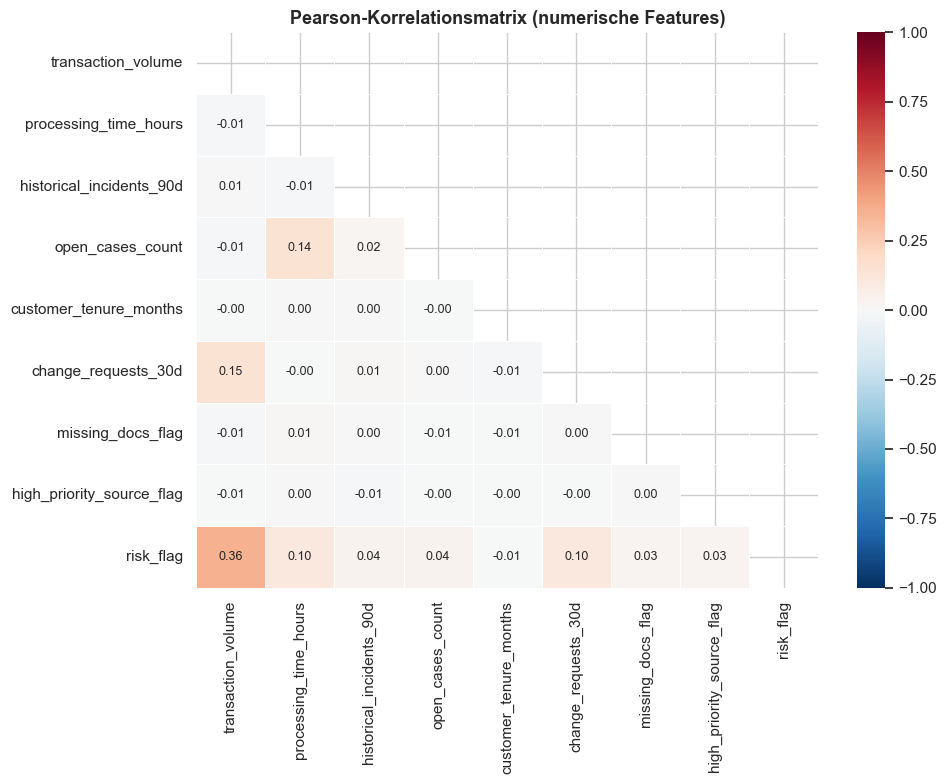

In [72]:
# Pearson-Korrelation (numerische Features + Target)
corr_cols = num_cols + [TARGET]
corr_matrix = df[corr_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    vmin=-1, vmax=1, center=0, linewidths=0.5, ax=ax,
    annot_kws={'size': 9}
)
ax.set_title('Pearson-Korrelationsmatrix (numerische Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

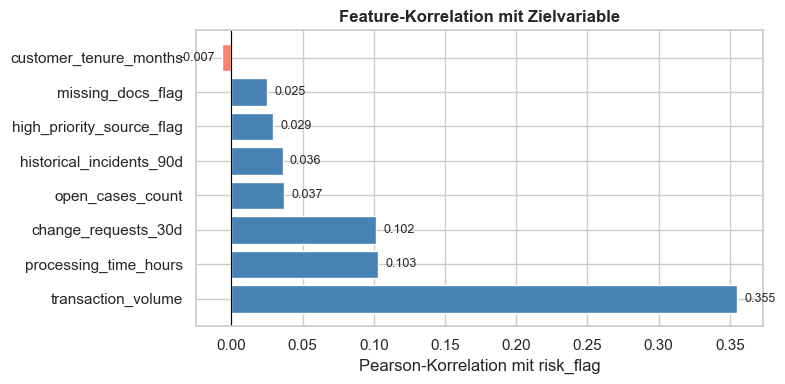

Top-Features (|corr| > 0.1):
transaction_volume      0.355
processing_time_hours   0.103
change_requests_30d     0.102


In [73]:
# Korrelation mit dem Target
target_corr = corr_matrix[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, max(4, len(target_corr) * 0.5)))
colors = ['salmon' if v < 0 else 'steelblue' for v in target_corr.values]
bars = ax.barh(target_corr.index, target_corr.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson-Korrelation mit risk_flag')
ax.set_title('Feature-Korrelation mit Zielvariable', fontsize=12, fontweight='bold')
for bar, val in zip(bars, target_corr.values):
    ax.text(val + (0.005 if val >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()

print('Top-Features (|corr| > 0.1):')
print(target_corr[abs(target_corr) > 0.1].to_string())

In [74]:
# Hochkorrelierte Feature-Paare identifizieren
high_corr_threshold = 0.8
corr_feat = df[num_cols].corr(method='pearson').abs()
upper_triangle = corr_feat.where(np.triu(np.ones(corr_feat.shape), k=1).astype(bool))
high_corr_pairs = [
    (col, row, upper_triangle.loc[row, col])
    for col in upper_triangle.columns
    for row in upper_triangle.index
    if pd.notna(upper_triangle.loc[row, col]) and upper_triangle.loc[row, col] > high_corr_threshold
]

if high_corr_pairs:
    print(f'Hochkorrelierte Paare (|r| > {high_corr_threshold}):')
    for f1, f2, r in sorted(high_corr_pairs, key=lambda x: -x[2]):
        print(f'  {f1} <-> {f2}: r = {r:.3f}')
else:
    print(f'Keine hochkorrelierten Paare (|r| > {high_corr_threshold}) gefunden.')

Keine hochkorrelierten Paare (|r| > 0.8) gefunden.


In [75]:
# Spearman-Korrelation (robuster gegen Ausreißer und monotone Nicht-Linearität)
spearman_corr = df[corr_cols].corr(method='spearman')
spearman_target = spearman_corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

comparison = pd.DataFrame({
    'Pearson': target_corr,
    'Spearman': spearman_target
}).sort_values('Spearman', key=abs, ascending=False)

print('Pearson vs. Spearman Korrelation mit risk_flag:')
display(comparison.style.background_gradient(cmap='RdBu_r', vmin=-1, vmax=1))

Pearson vs. Spearman Korrelation mit risk_flag:


,Pearson,Spearman
transaction_volume,0.355248,0.334353
change_requests_30d,0.101845,0.098741
processing_time_hours,0.103262,0.089858
open_cases_count,0.037100,0.035291
historical_incidents_90d,0.036036,0.030221
high_priority_source_flag,0.029310,0.029310
missing_docs_flag,0.025350,0.025350
customer_tenure_months,-0.006602,-0.007670


## 7. Multikollinearität (VIF)

,Feature,VIF,Bewertung
0,transaction_volume,1.022203,ok (<5)
5,change_requests_30d,1.022152,ok (<5)
1,processing_time_hours,1.020849,ok (<5)
3,open_cases_count,1.020723,ok (<5)
2,historical_incidents_90d,1.000673,ok (<5)
6,missing_docs_flag,1.000387,ok (<5)
4,customer_tenure_months,1.000227,ok (<5)
7,high_priority_source_flag,1.000136,ok (<5)


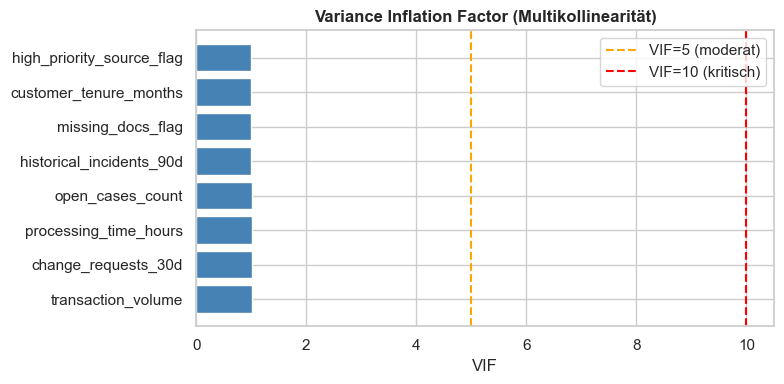

In [76]:
# Variance Inflation Factor
X_vif = df[num_cols].dropna()
X_vif_const = add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [
    variance_inflation_factor(X_vif_const.values, i + 1)
    for i in range(X_vif.shape[1])
]
vif_data = vif_data.sort_values('VIF', ascending=False)
vif_data['Bewertung'] = vif_data['VIF'].apply(
    lambda v: 'kritisch (>10)' if v > 10
    else ('moderat (5-10)' if v > 5 else 'ok (<5)')
)

display(vif_data.style.apply(
    lambda row: ['background-color: #ffcccc' if row['Bewertung'] == 'kritisch (>10)'
                 else ('background-color: #fff3cc' if row['Bewertung'] == 'moderat (5-10)'
                 else '') for _ in row], axis=1
))

fig, ax = plt.subplots(figsize=(8, max(4, len(vif_data) * 0.5)))
colors = ['red' if v > 10 else ('orange' if v > 5 else 'steelblue') for v in vif_data['VIF']]
ax.barh(vif_data['Feature'], vif_data['VIF'], color=colors)
ax.axvline(x=5, color='orange', linestyle='--', linewidth=1.5, label='VIF=5 (moderat)')
ax.axvline(x=10, color='red', linestyle='--', linewidth=1.5, label='VIF=10 (kritisch)')
ax.set_xlabel('VIF')
ax.set_title('Variance Inflation Factor (Multikollinearität)', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Feature-Relevanz: Bivariate Analyse (Feature vs. Target)

In [77]:
# Chi-Quadrat-Test: kategorische Features vs. Target
from scipy.stats import chi2_contingency

print('Chi-Quadrat-Test: kategorische Features vs. risk_flag\n')
chi2_results = []
for col in cat_cols:
    ct = pd.crosstab(df[col], df[TARGET])
    chi2, p, dof, _ = chi2_contingency(ct)
    chi2_results.append({'Feature': col, 'Chi2': chi2, 'p-Wert': p, 'DOF': dof,
                          'Signifikant': 'Ja' if p < 0.05 else 'Nein'})

chi2_df = pd.DataFrame(chi2_results).sort_values('Chi2', ascending=False)
display(chi2_df)

Chi-Quadrat-Test: kategorische Features vs. risk_flag



,Feature,Chi2,p-Wert,DOF,Signifikant
1,channel,56.168,0.000,3,Ja
0,region,34.895,0.000,3,Ja
2,customer_segment,26.251,0.000,2,Ja
3,product_line,19.533,0.000,3,Ja


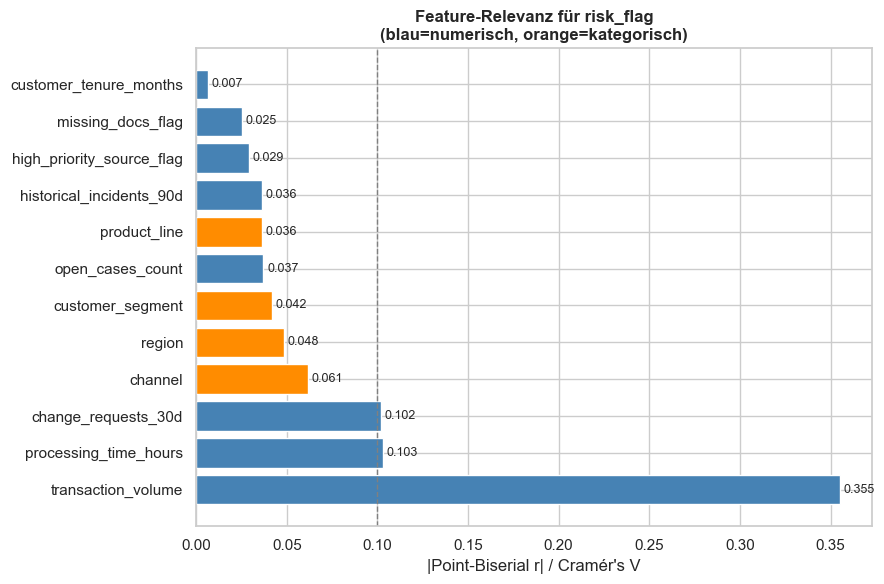


Feature-Relevanz-Ranking:


,Feature,Typ,Korrelation/Assoziation,p-Wert
0,transaction_volume,numerisch,0.355248,0.000000
1,processing_time_hours,numerisch,0.103262,0.000000
5,change_requests_30d,numerisch,0.101845,0.000000
9,channel,kategorisch,0.061451,0.000000
8,region,kategorisch,0.048232,0.000000
10,customer_segment,kategorisch,0.041834,0.000002
3,open_cases_count,numerisch,0.037100,0.000005
11,product_line,kategorisch,0.036086,0.000212
2,historical_incidents_90d,numerisch,0.036036,0.000010
7,high_priority_source_flag,numerisch,0.029310,0.000330


In [78]:
# Point-Biserial Korrelation & Cramér's V Zusammenfassung
from scipy.stats import pointbiserialr

feature_relevance = []
for col in num_cols:
    valid = df[[col, TARGET]].dropna()
    r, p = pointbiserialr(valid[col], valid[TARGET])
    feature_relevance.append({'Feature': col, 'Typ': 'numerisch', 'Korrelation/Assoziation': abs(r), 'p-Wert': p})

for col in cat_cols:
    ct = pd.crosstab(df[col], df[TARGET])
    chi2, p, _, _ = chi2_contingency(ct)
    n = ct.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    feature_relevance.append({'Feature': col, 'Typ': 'kategorisch', 'Korrelation/Assoziation': cramers_v, 'p-Wert': p})

relevance_df = pd.DataFrame(feature_relevance).sort_values('Korrelation/Assoziation', ascending=False)

fig, ax = plt.subplots(figsize=(9, max(4, len(relevance_df) * 0.5)))
colors = ['steelblue' if t == 'numerisch' else 'darkorange' for t in relevance_df['Typ']]
bars = ax.barh(relevance_df['Feature'], relevance_df['Korrelation/Assoziation'], color=colors)
ax.set_xlabel('|Point-Biserial r| / Cramér\'s V')
ax.set_title('Feature-Relevanz für risk_flag\n(blau=numerisch, orange=kategorisch)',
             fontsize=12, fontweight='bold')
ax.axvline(0.1, color='gray', linestyle='--', linewidth=1, label='Schwelle 0.1')
for bar, val in zip(bars, relevance_df['Korrelation/Assoziation']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('\nFeature-Relevanz-Ranking:')
display(relevance_df.style.bar(subset=['Korrelation/Assoziation'], color='steelblue'))

## 10. Problemformulierung

### Zielvariable
`risk_flag` (binär: 0 = kein Risiko, 1 = Risiko) — Klassifikationsaufgabe.

### Anwendungsfall
Frühzeitige automatische Erkennung risikobehafteter Transaktionen/Fälle im operativen Betrieb, um manuelle Prüfkapazitäten gezielt einzusetzen.

### Nutzen
- Priorisierung von Hochrisikofällen vor manueller Bearbeitung
- Reduktion von Bearbeitungsaufwand durch automatisches Screening
- Frühwarnsystem für kritische Ereignisse

### Risiken
- **False Negatives** (Risikofall nicht erkannt) sind geschäftlich kritischer als False Positives
- Modell darf nicht als alleinige Entscheidungsinstanz genutzt werden
- Bei Konzeptdrift muss das Modell zeitnah aktualisiert werden

## 11. Metriken

Da False Negatives geschäftlich schwerwiegender sind als False Positives, priorisieren wir **Recall** für Klasse 1, verwenden aber **F1-Score** als Hauptmetrik um Precision nicht vollständig zu opfern.

| Metrik | Begründung |
|--------|------------|
| **F1 (Klasse 1)** | Hauptmetrik — Balance Precision/Recall bei Imbalance (65/35) |
| **Recall (Klasse 1)** | Kritisch — Risikofälle dürfen nicht übersehen werden |
| **ROC-AUC** | Schwellenwert-unabhängige Gesamtperformance |
| **Precision (Klasse 1)** | Kontrolle gegen zu viele False Positives |

**Accuracy wird nicht als primäre Metrik verwendet**, da ein naives Modell, das immer Klasse 0 vorhersagt, bereits 65.6% Accuracy erreichen würde.

In [79]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, f1_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Naive Baseline: immer häufigste Klasse
dummy = DummyClassifier(strategy='most_frequent')
y_dummy = [0] * len(df)
print('Naive Baseline (immer Klasse 0):')
print(f'  Accuracy: {(df[TARGET] == 0).mean():.3f}')
print(f'  F1 (Klasse 1): 0.000  <- warum Accuracy allein täuscht')
print(f'  => Ziel-F1 des Modells muss deutlich > 0.0 liegen')

Naive Baseline (immer Klasse 0):
  Accuracy: 0.656
  F1 (Klasse 1): 0.000  <- warum Accuracy allein täuscht
  => Ziel-F1 des Modells muss deutlich > 0.0 liegen


## 12. Datensplit (zeitbasiert)

Der Datensatz hat eine **zeitliche Struktur** (Jan–Apr 2025). Ein zufälliger Split würde Data Leakage erzeugen, da zukünftige Daten zum Training genutzt würden.

**Strategie: Zeitbasierter Split**
- **Training:** Januar – März 2025 (~12.000 Fälle, 80%)
- **Test:** April 2025 (~3.000 Fälle, 20%)

**Begründung:**
- Simuliert realen Produktionsbetrieb: Modell wird auf vergangenen Daten trainiert und auf zukünftigen evaluiert
- Verhindert Leakage durch zeitliche Abhängigkeiten
- April dient später auch als Basis für Drift-Monitoring (AP 5)

In [80]:
# Zeitbasierter Train/Test-Split
df['timestamp'] = pd.to_datetime(df['timestamp'])

SPLIT_DATE = '2025-04-01'
train_df = df[df['timestamp'] < SPLIT_DATE].copy()
test_df  = df[df['timestamp'] >= SPLIT_DATE].copy()

print(f'Trainingszeitraum: {train_df["timestamp"].min().date()} bis {train_df["timestamp"].max().date()}')
print(f'Testzeitraum:      {test_df["timestamp"].min().date()} bis {test_df["timestamp"].max().date()}')
print(f'Train: {len(train_df):,} Zeilen ({len(train_df)/len(df)*100:.1f}%)')
print(f'Test:  {len(test_df):,} Zeilen ({len(test_df)/len(df)*100:.1f}%)')
print()
print('Klassenverteilung Train:')
print(train_df[TARGET].value_counts(normalize=True).round(3))
print('Klassenverteilung Test:')
print(test_df[TARGET].value_counts(normalize=True).round(3))

Trainingszeitraum: 2025-01-01 bis 2025-03-31
Testzeitraum:      2025-04-01 bis 2025-04-30
Train: 12,000 Zeilen (80.0%)
Test:  3,000 Zeilen (20.0%)

Klassenverteilung Train:
risk_flag
0   0.654
1   0.346
Name: proportion, dtype: float64
Klassenverteilung Test:
risk_flag
0   0.667
1   0.333
Name: proportion, dtype: float64


## 13. Fazit & Empfehlungen

### Preprocessing-Checkliste für das Modell-Training

#### 1. Missing Values

3 Features mit fehlenden Werten — Imputation notwendig:

| Feature | Fehlend | Strategie |
|---|---|---|
| `customer_tenure_months` | 275 (1.83%) | Median-Imputation |
| `processing_time_hours` | 236 (1.57%) | Median-Imputation |
| `channel` | 126 (0.84%) | Mode-Imputation oder Kategorie "Unknown" |

#### 2. Schiefe Features (Skewness)
Alle numerischen Features haben ausschließlich positive Werte — `log1p` ist überall anwendbar.

Empfehlung nach Skewness-Stärke:

| Feature | Skewness | Empfehlung |
|---|---|---|
| `missing_docs_flag` | 2.34 | Binär — keine Transformation |
| `high_priority_source_flag` | 1.52 | Binär — keine Transformation |
| `processing_time_hours` | 1.15 | `log1p` |
| `transaction_volume` | 0.89 | `log1p` |
| `historical_incidents_90d` | 0.78 | `log1p` |
| `change_requests_30d` | 0.77 | `log1p` |
| `open_cases_count` | 0.50 | kein Handlungsbedarf |
| `customer_tenure_months` | 0.12 | kein Handlungsbedarf |

#### 3. Ausreißer
Echte Ausreißer in `historical_incidents_90d` (7.9%), `processing_time_hours` (2.5%) und `transaction_volume` (2.1%) — bei baumbasierten Modellen kein Handlungsbedarf. Bei linearer / logistischer Regression: Capping auf das 99. Perzentil.

#### 4. Kategorische Features
Alle 4 Features (`region`, `channel`, `customer_segment`, `product_line`) sind signifikant mit `risk_flag` assoziiert und werden mit **One-Hot Encoding** enkodiert (max. 4 Kategorien pro Feature, kein High-Cardinality-Problem).

#### 5. Feature-Relevanz
- `transaction_volume` stärkster Prädiktor (r ≈ 0.36) — behalten.
- Alle anderen Features behalten — auch schwächere Features können in Kombination nützlich sein.

#### 6. Multikollinearität
Keine hochkorrelierten Feature-Paare (|r| > 0.8) — kein Feature-Dropping notwendig